# <p align  = "center"> Data Sizes Analysis </p>

In [1]:
#Initialize Notebook Environment
from pathlib import Path
import sys
sys.path.insert( 0, Path("../..").resolve().absolute().__str__() )

- Loading Data

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xaidar.filesUtils import loadPickle

xc_dataDir = Path( "../../../data/s3Sizes/xchem/filetypes" )
xc_dataStats = loadPickle( xc_dataDir / "stats_filetype_sizes.pkl" )
xc_dataStats_df = pd.DataFrame( xc_dataStats )

pd_dataDir = Path( "../../../data/s3Sizes/pandda/filetypes" )
pd_dataStats = loadPickle( pd_dataDir / "stats_filetype_sizes.pkl" )
pd_dataStats_df = pd.DataFrame( pd_dataStats )

print( "XChem Data Statistics:" )
display( xc_dataStats_df.head(2))
print( "Pandda Data Statistics:" )
display( pd_dataStats_df.head(2) )


XChem Data Statistics:


,File Type,Files Count,Median,Mean,Std,1stQrt,3rdQrt,QrtDeviation,Max,Min,Sum
0,.csv,492956,1860.0,13679.315385,3.242432e+05,1356.0,3357.0,1000.5,80906623,0,6743300595
1,.txt,3458488,10672.0,304168.266793,3.178951e+06,1380.0,25226.0,11923.0,487143107,0,1051962300685


Pandda Data Statistics:


,File Type,Files Count,Median,Mean,Std,1stQrt,3rdQrt,QrtDeviation,Max,Min,Sum
0,.csv,168,61908.0,239908.482143,489547.716090,23280.75,228948.0,102833.625,3606844,3,40304625
1,.log,608435,9143.0,20228.220240,22693.793181,738.00,39411.0,19336.500,309100,0,12307557182


In [27]:
# Table Hihgest Sum
print( "Top 2 File Types by Sum Size in XChem:" )
display( xc_dataStats_df.sort_values(by=[ "Sum", "Files Count",], ascending=[False, False])[["File Type", "Sum", "Files Count"]][:2] )
print( "Top 2 File Types by Sum Size in Pandda:" )
display( pd_dataStats_df.sort_values(by=[ "Sum", "Files Count",], ascending=[False, False])[["File Type", "Sum", "Files Count"]][:2])

Top 2 File Types by Sum Size in XChem:


,File Type,Sum,Files Count
337,.ccp4,43335563627385,2007939
11,.mtz,37612329367516,7623701


Top 2 File Types by Sum Size in Pandda:


,File Type,Sum,Files Count
7,.ccp4,7791652589728,900842
8,.mtz,336014350808,96111


In [28]:
# Table Highest Count
print( "Top 2 File Types by Count in XChem:" )
display( xc_dataStats_df.sort_values(by=[ "Files Count", "Sum",], ascending=[False, False])[["File Type", "Sum", "Files Count"]][:2])
print( "Top 2 File Types by Count in Pandda:" )
display( pd_dataStats_df.sort_values(by=[ "Files Count", "Sum",], ascending=[False, False])[["File Type", "Sum", "Files Count"]][:2])

Top 2 File Types by Count in XChem:


,File Type,Sum,Files Count
10,.pdb,2355704041649,22971408
6,.log,1627444661489,20414437


Top 2 File Types by Count in Pandda:


,File Type,Sum,Files Count
6,.pdb,264404634326,2053436
7,.ccp4,7791652589728,900842


- Totals Statisic Values

In [42]:
xc_bucketSize = xc_dataStats_df["Sum"].sum()
xc_bucketCount = xc_dataStats_df["Files Count"].sum()
# xc_bucketMedians = xc_dataStats_df["Median"].sum()

pd_bucketSize = pd_dataStats_df["Sum"].sum()
pd_bucketCount = pd_dataStats_df["Files Count"].sum()
# pandda_bucketMedians = pd_dataStats_df["Median"].sum()

print( "xchem Bucket Statistics:" )
print( f"\tTotal bucket size: {round( xc_bucketSize / 1e12, 2)} TB" )
print( f"\tTotal files count: {round( xc_bucketCount / 1e6 , 2)} Million" )

print( "pandda Bucket Statistics:" )
print( f"\tTotal bucket size: {round( pd_bucketSize / 1e12, 2)} TB" )
print( f"\tTotal files count: {round( pd_bucketCount / 1e6 , 2)} Million" )

xchem Bucket Statistics:
	Total bucket size: 156.15 TB
	Total files count: 129.66 Million
pandda Bucket Statistics:
	Total bucket size: 8.47 TB
	Total files count: 5.12 Million


- Per File Type Statistics

In [30]:
# Filtering Odd Files
import re

xc_lstFileTypes = list(xc_dataStats_df["File Type"].values)

xc_removedFileTypes = [ file for file in list(xc_lstFileTypes) if re.search( "^\\....[0-9][0-9][0-9]", file) ] 
xc_updatedFileTypes = [ file for file in list(xc_lstFileTypes) if not re.search( "^\\....[0-9][0-9][0-9]", file)]

xc_removedFileTypes.extend( [ file for file in xc_updatedFileTypes if  re.search( "^\\.[0-9][0-9][0-9][0-9]", file)] )# i.e. .21610_VDW_R
xc_updatedFileTypes = [ file for file in xc_updatedFileTypes if not re.search( "^\\.[0-9][0-9][0-9][0-9]", file)]  # i.e. .21610_VDW_R

xc_removedFileTypes.extend( [ file for file in xc_updatedFileTypes if  re.search( "[0-9][0-9][0-9][0-9][0-9][0-9][0-9]", file)] )
xc_updatedFileTypes = [ file for file in xc_updatedFileTypes if not re.search( "[0-9][0-9][0-9][0-9][0-9][0-9][0-9]", file)]  


xc_updatedFileTypes = sorted( xc_updatedFileTypes)
xc_removedFileTypes = sorted( xc_removedFileTypes)

print(f"Number of File types after removing odds ones: {len(xc_updatedFileTypes)}")
print(f"Number of Removed File types: {len(xc_removedFileTypes)}")

pd_lstFileTypes = list(pd_dataStats_df["File Type"].values)

pd_removedFileTypes = [ file for file in list(pd_lstFileTypes) if re.search( "^\\....[0-9][0-9][0-9]", file) ]
pd_updatedFileTypes = [ file for file in list(pd_lstFileTypes) if not re.search( "^\\....[0-9][0-9][0-9]", file)]

pd_removedFileTypes.extend( [ file for file in pd_updatedFileTypes if  re.search( "^\\.[0-9][0-9][0-9][0-9]", file)] )# i.e. .21610_VDW_R
pd_updatedFileTypes = [ file for file in pd_updatedFileTypes if not re.search( "^\\.[0-9][0-9][0-9][0-9]", file)]  # i.e. .21610_VDW_R

pd_removedFileTypes.extend( [ file for file in pd_updatedFileTypes if  re.search( "[0-9][0-9][0-9][0-9][0-9][0-9][0-9]", file)] )
pd_updatedFileTypes = [ file for file in pd_updatedFileTypes if not re.search( "[0-9][0-9][0-9][0-9][0-9][0-9][0-9]", file)]

pd_updatedFileTypes = sorted( pd_updatedFileTypes)
pd_removedFileTypes = sorted( pd_removedFileTypes)

print(f"Number of File types after removing odds ones: {len(pd_updatedFileTypes)}")
print(f"Number of Removed File types: {len(pd_removedFileTypes)}")
# # Displaying removed file types
# for i in range( len( removedFileTypes[:] )//20 ):
#     # print( removedFileTypes[i*20:(i+1)*20] )
#     print( removedFileTypes[-(i+1)*20: -i*20:] )

Number of File types after removing odds ones: 8875
Number of Removed File types: 257657
Number of File types after removing odds ones: 75
Number of Removed File types: 76


In [31]:
# Instantiate Objects to Plot
xc_sums =  xc_dataStats_df.sort_values( by=[ "Sum"], ascending=[False] )
xc_counts =  xc_dataStats_df.sort_values( by=[ "Files Count"], ascending=[False] ) 

pd_sums =  pd_dataStats_df.sort_values( by=[ "Sum"], ascending=[False] )
pd_counts =  pd_dataStats_df.sort_values( by=[ "Files Count"], ascending=[False] ) 
# median = xc_dataStats_df.sort_values( by=[ "Median"], ascending=[False] ) 
pd_setRemovedFileTypes = set(pd_removedFileTypes)
pd_filteredsums = pd_dataStats_df[ ( [fileType not in pd_setRemovedFileTypes for fileType in  pd_dataStats_df["File Type"] ]  )].sort_values( by=[ "Sum"], ascending=[False] )
# filteredMedian = xc_dataStats_df[ ( [fileType not in setRemovedFileTypes for fileType in  xc_dataStats_df["File Type"] ]  )].sort_values( by=[ "Median"], ascending=[False] )

xchem Bucket Statistics:
	Total bucket size: 156.15 TB
	Total files count: 129.66 Million
pandda Bucket Statistics:
	Total bucket size: 8.47 TB
	Total files count: 5.12 Million


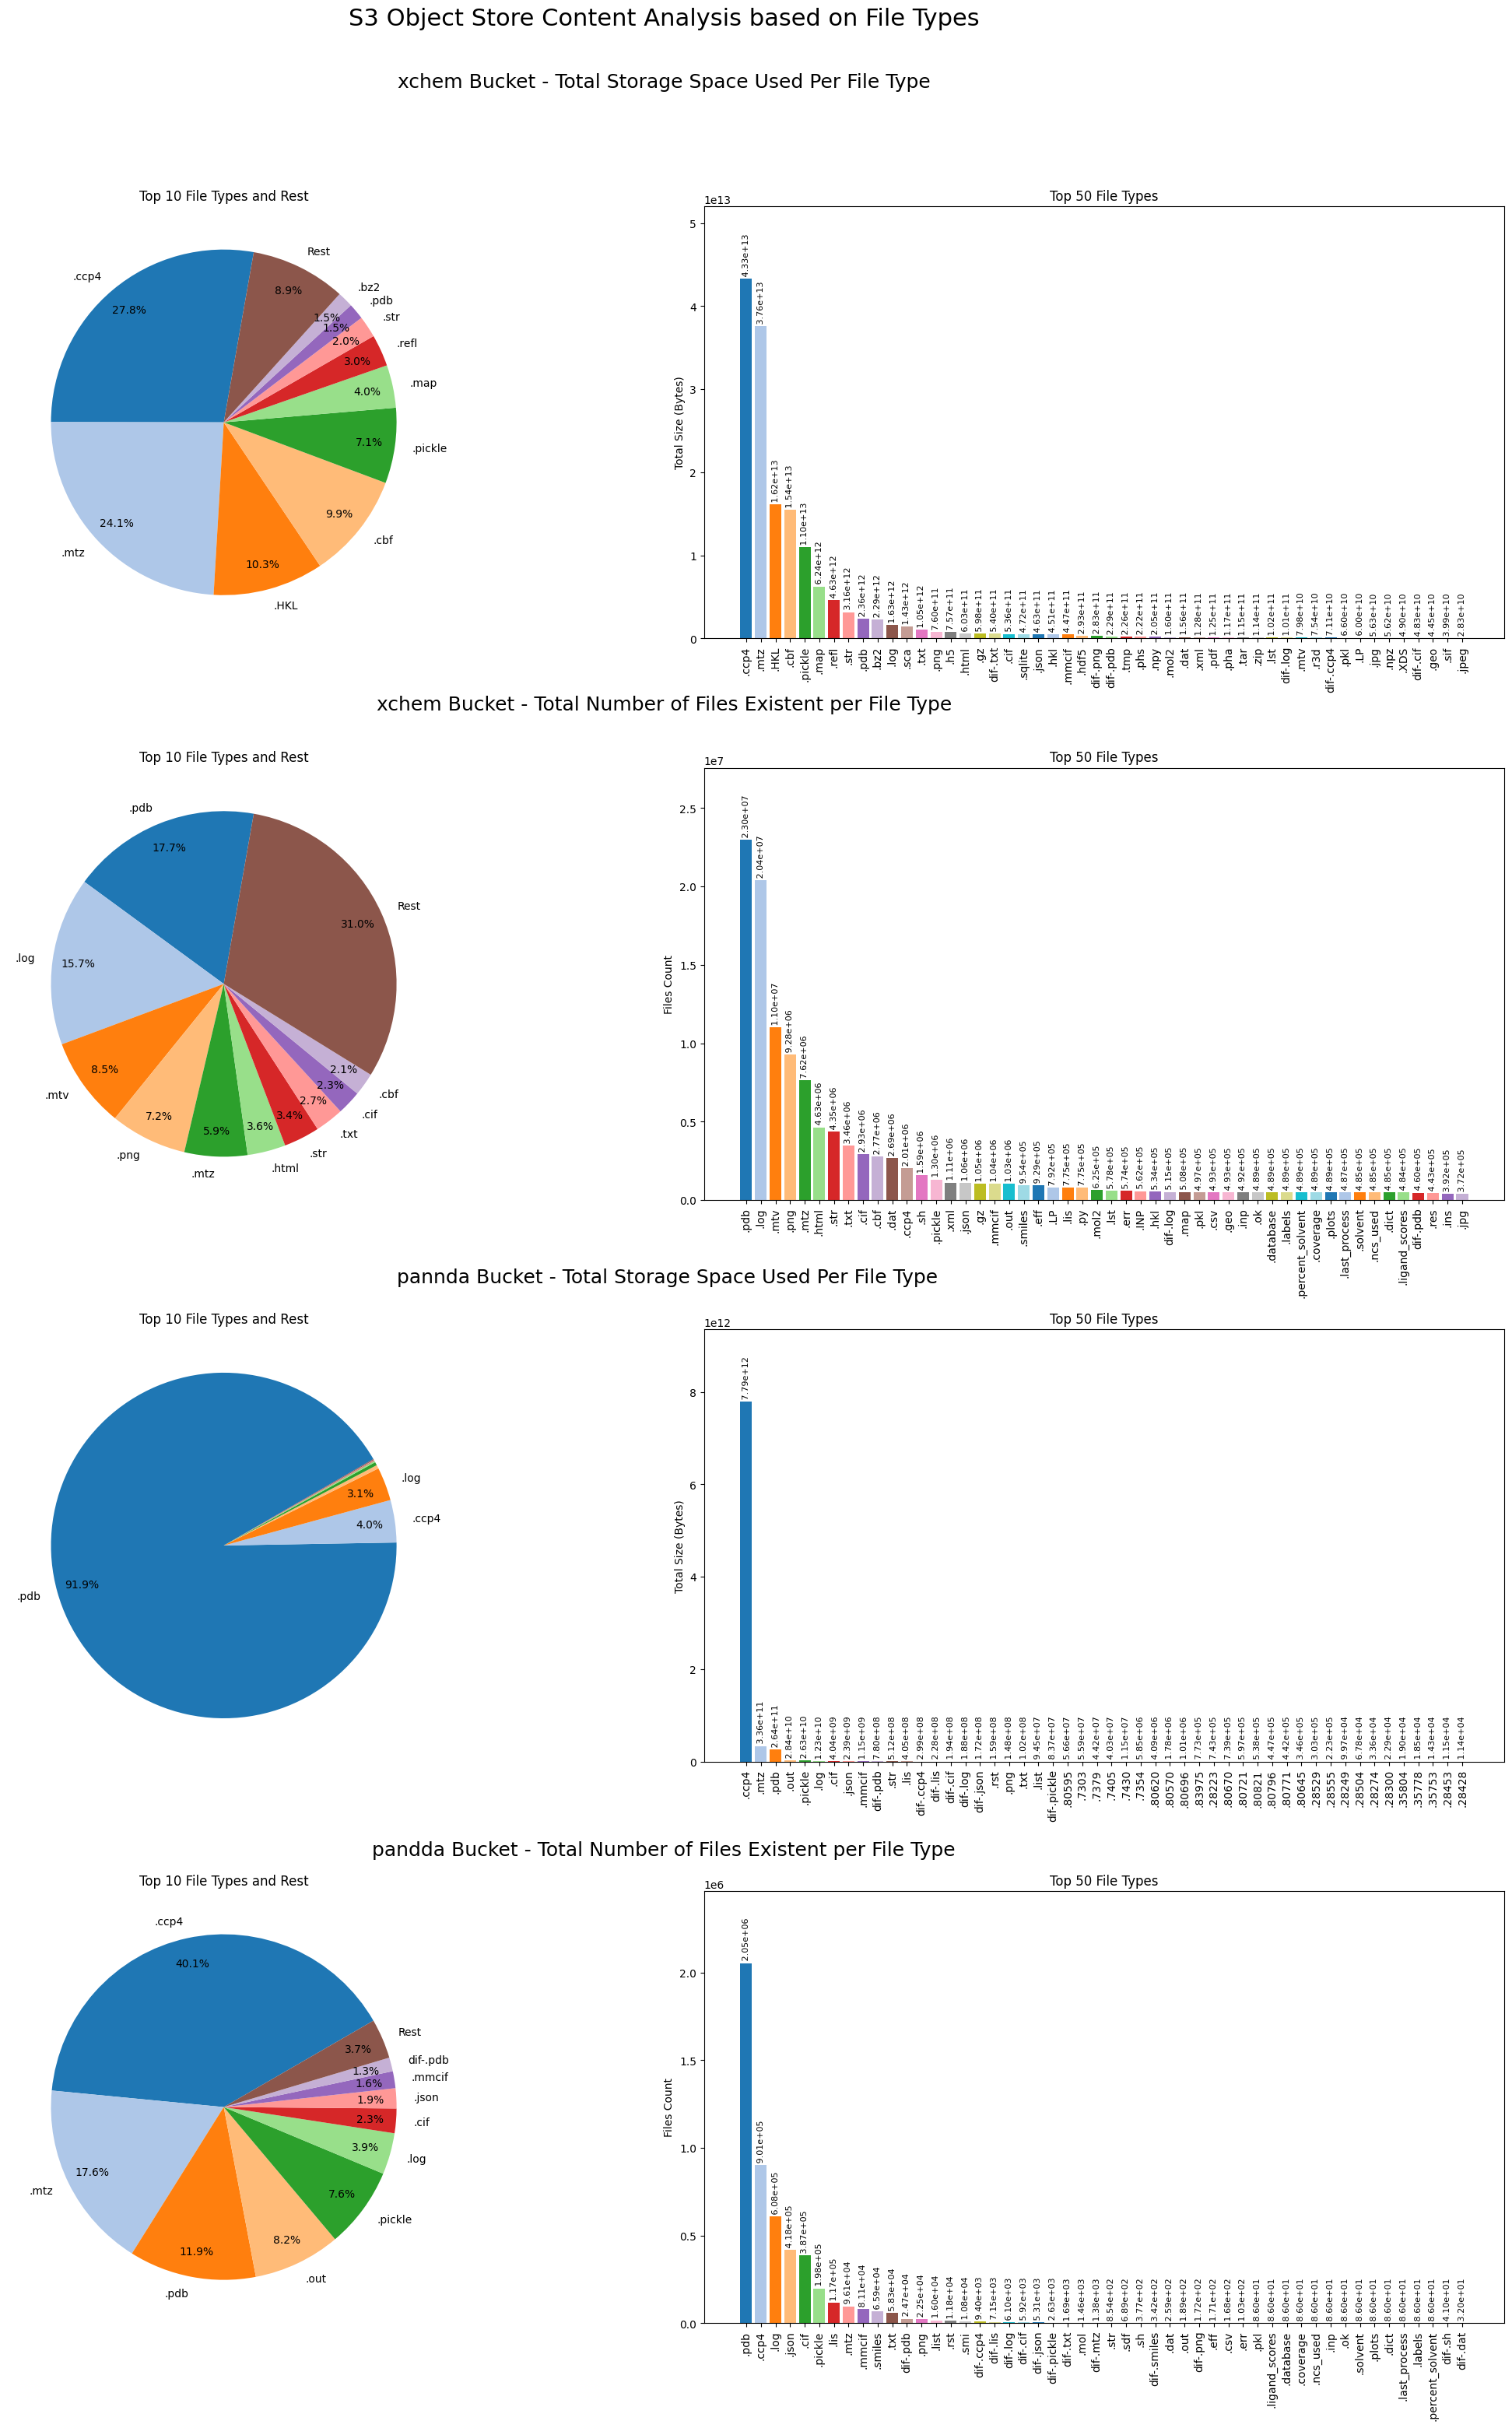

In [60]:
# Plotting the Data
import matplotlib.pyplot as plt
import seaborn as sns

print( "xchem Bucket Statistics:" )
print( f"\tTotal bucket size: {round( xc_bucketSize / 1e12, 2)} TB" )
print( f"\tTotal files count: {round( xc_bucketCount / 1e6 , 2)} Million" )

print( "pandda Bucket Statistics:" )
print( f"\tTotal bucket size: {round( pd_bucketSize / 1e12, 2)} TB" )
print( f"\tTotal files count: {round( pd_bucketCount / 1e6 , 2)} Million" )

fig, ax = plt.subplots(4, 2, figsize=(24, 32))
# fig, ax = plt.subplots(2, 2, figsize=(24, 16))
# fig.tight_layout(h_pad=2)


ax[0,0].pie( list(xc_sums["Sum"][:10]) + [xc_bucketSize - sum(xc_sums["Sum"][:10])], labels= list(xc_sums["File Type"][:10] ) + ["Rest"],
            colors = sns.color_palette("tab20"), autopct='%1.1f%%', pctdistance=0.85,  startangle=80) #
ax[0,0].set_title("Top 10 File Types and Rest")


ax[0,1].bar(xc_sums["File Type"][:50], xc_sums["Sum"][:50], color=sns.color_palette("tab20"))
ax[0,1].set_title("Top 50 File Types")
ax[0,1].tick_params(axis='x', rotation=90)
ax[0,1].set_ylim(0, max(xc_sums["Sum"][:50]) * 1.2)  # Set y-axis limit to 110% of the max value
ax[0,1].set_ylabel("Total Size (Bytes)")
# Add values on top of each bar
for idx, value in enumerate(xc_sums["Sum"][:50]):
    ax[0,1].text(idx, value, f' {value:.2e}', ha='center', va='bottom', fontsize=8, rotation=90)

# ax[0,1].pie(sums["Sum"][:10], labels=sums["File Type"][:10],colors = sns.color_palette("tab20"), autopct='%1.1f%%', startangle=140)
# ax[0,1].set_title("Top 10 File Types")


ax[1,0].pie( list(xc_counts["Files Count"][:10]) + [ xc_bucketCount - sum(xc_counts["Files Count"][:10])], labels = (list(xc_counts["File Type"][:10] ) + ["Rest"] ),
            colors = sns.color_palette("tab20"),autopct='%1.1f%%', pctdistance=0.85,  startangle=80)
ax[1,0].set_title("Top 10 File Types and Rest")


ax[1,1].bar(xc_counts["File Type"][:50], xc_counts["Files Count"][:50], color=sns.color_palette("tab20"))
ax[1,1].set_title("Top 50 File Types")
ax[1,1].tick_params(axis='x', rotation=90)
ax[1,1].set_ylim(0, max(xc_counts["Files Count"][:50]) * 1.2)  # Set y-axis limit to 110% of the max value
ax[1,1].set_ylabel("Files Count")
# Add values on top of each bar
for idx, value in enumerate(xc_counts["Files Count"][:50]):
    ax[1,1].text(idx, value, f' {value:.2e}', ha='center', va='bottom', fontsize=8, rotation=90)

def show_pct_for_largest_two(pct):
    """
    A function for autopct that returns a formatted percentage string
    for the two largest values and an empty string for others.
    """
    sizes = list(pd_filteredsums["Sum"][:10]) + [pd_bucketSize - sum(pd_filteredsums["Sum"][:10])]

    # Find the threshold value (the value of the 2nd largest slice)
    threshold = sorted(sizes, reverse=True)[2]
    
    # Calculate the absolute value corresponding to the percentage
    absolute_value = pct/100.*np.sum(sizes)
    
    # If the slice's value is one of the two largest, show the percentage
    if absolute_value >= threshold:
        return f'{pct:.1f}%'
    else:
        return ''


ax[2,0].pie( list(pd_filteredsums["Sum"][:10]) + [pd_bucketSize - sum(pd_filteredsums["Sum"][:10])], labels=  ( list(pd_counts["File Type"][:10] )[:3] + [ ""  for _ in range( 11-3) ]  ), # list(pd_filteredsums["File Type"][:10] ) + ["Rest"],
            colors = sns.color_palette("tab20"), autopct= show_pct_for_largest_two, pctdistance=0.85,  startangle= 30) #
ax[2,0].set_title("Top 10 File Types and Rest")


ax[2,1].bar(pd_sums["File Type"][:50], pd_sums["Sum"][:50], color=sns.color_palette("tab20"))
ax[2,1].set_title("Top 50 File Types")
ax[2,1].tick_params(axis='x', rotation=90)
ax[2,1].set_ylim(0, max(pd_filteredsums["Sum"][:50]) * 1.2)  # Set y-axis limit to 110% of the max value
ax[2,1].set_ylabel("Total Size (Bytes)")
# Add values on top of each bar
for idx, value in enumerate(pd_filteredsums["Sum"][:50]):
    ax[2,1].text(idx, value, f' {value:.2e}', ha='center', va='bottom', fontsize=8, rotation=90)

# ax[0,1].pie(sums["Sum"][:10], labels=sums["File Type"][:10],colors = sns.color_palette("tab20"), autopct='%1.1f%%', startangle=140)
# ax[0,1].set_title("Top 10 File Types")


ax[3,0].pie( list(pd_counts["Files Count"][:10]) + [ pd_bucketCount - sum(pd_counts["Files Count"][:10])], labels = (  list(pd_filteredsums["File Type"][:10] ) + ["Rest"]) ,
            colors = sns.color_palette("tab20"),autopct='%1.1f%%', pctdistance=0.85,  startangle=30)
ax[3,0].set_title("Top 10 File Types and Rest")


ax[3,1].bar(pd_counts["File Type"][:50], pd_counts["Files Count"][:50], color=sns.color_palette("tab20"))
ax[3,1].set_title("Top 50 File Types")
ax[3,1].tick_params(axis='x', rotation=90)
ax[3,1].set_ylim(0, max(pd_counts["Files Count"][:50]) * 1.2)  # Set y-axis limit to 110% of the max value
ax[3,1].set_ylabel("Files Count")
# Add values on top of each bar
for idx, value in enumerate(pd_counts["Files Count"][:50]):
    ax[3,1].text(idx, value, f' {value:.2e}', ha='center', va='bottom', fontsize=8, rotation=90)


fig.suptitle("S3 Object Store Content Analysis based on File Types", fontsize=22)
fig.text(0.5, 0.95, "xchem Bucket - Total Storage Space Used Per File Type", ha='center', va='center', fontsize=18)
fig.text(0.5, 0.70, "xchem Bucket - Total Number of Files Existent per File Type", ha='center', va='center', fontsize=18)
fig.text(0.5, 0.47, " pannda Bucket - Total Storage Space Used Per File Type", ha='center', va='center', fontsize=18)
fig.text(0.5, 0.24, "pandda Bucket - Total Number of Files Existent per File Type", ha='center', va='center', fontsize=18)
fig.savefig("s3-FileTypesContent.png", dpi=400)
plt.subplots_adjust(top=0.90, bottom=0.05, left=0.05, right=0.95, hspace=0.3, wspace=0.1)
plt.show()

# To increase the quality of a matplotlib plot, you can save the figure with a higher DPI (dots per inch).
# Example:


## Variation and Distribution per File Type

In [ ]:
from xaidar.filesUtils import loadPickle

dataPath = Path( "../../data/s3Sizes/xchem/filetypes/merged_filetype_sizes.pkl" ) 
data = loadPickle( dataPath )

# data_df = pd.DataFrame( data )
# display( data_df.head(2))

## Looking at ccp4 sub types

In [3]:
from xaidar.filesUtils import loadPickle
result = loadPickle(Path( "../../../data/s3Sizes/ccp4Files.pkl") )

In [66]:
# Looking at xchem first


print(list( result["xchem"].keys() )[:5] )
lstCcp4Names = list( zip( *list(  result["xchem"].values() ) ) ) 
print( len(lstCcp4Names))
print( len( lstCcp4Names[0]), len( lstCcp4Names[1]))
print(  lstCcp4Names[0][:3],  lstCcp4Names[1][:3])


length = len( result["xchem"] )
totalSize = sum( lstCcp4Names[1] )
totalSize_GB = round( totalSize / (1e9), 3)
print( f"Number of ccp4 files in xchem: { length}" )
print( f"Space taken by ccp4 files in xchem: {totalSize_GB} GB")
# print( lstCcp4Names[:2])

['data/2015/lb13320-1/processing/analysis/backup/pandda/interesting_datasets/SHH-x1009/SHH-x1009-aligned-map.ccp4', 'data/2015/lb13320-1/processing/analysis/backup/pandda/interesting_datasets/SHH-x1009/SHH-x1009-difference-from-mean.ccp4', 'data/2015/lb13320-1/processing/analysis/backup/pandda/interesting_datasets/SHH-x1009/SHH-x1009-event_1_occupancy_1.0_map.ccp4', 'data/2015/lb13320-1/processing/analysis/backup/pandda/interesting_datasets/SHH-x1009/SHH-x1009-event_1_occupancy_1.0_map.native.ccp4', 'data/2015/lb13320-1/processing/analysis/backup/pandda/interesting_datasets/SHH-x1009/SHH-x1009-observed.native.ccp4']
2
2007939 2007939
('SHH-x1009-aligned-map.ccp4', 'SHH-x1009-difference-from-mean.ccp4', 'SHH-x1009-event_1_occupancy_1.0_map.ccp4') (7367488, 7367488, 7367488)
Number of ccp4 files in xchem: 2007939
Space taken by ccp4 files in xchem: 43335.564 GB


In [ ]:
print(lstCcp4Names[0][:5] )

In [24]:
num = 5
for i in range( 200000, 200100): #  len(lstCcp4Names[0]) // num
    print(lstCcp4Names[0][i*num : (i+1)*num] )

lst_regexs = [ "-aligned-map\.ccp4$",
              "difference-from-mean\.ccp4$",
              
              "-event_[0-9]+_occupancy_.+_map\.ccp4$",
              "-event_[0-9]+_occupancy_.+_map\.native\.ccp4$",
              
              "-event_.+-BDC_.+_map\.ccp4$",
              "-event_.+-BDC_.+_map\.native\.ccp4$",
              
              "-observed\.native.ccp4$",
              
              "-z_map\.ccp4$",
              "z_map.native.ccp4$", 

              "_mask.ccp4", #  'total_mask.ccp4' 'protein_mask.ccp4' 'symmetry_mask.ccp4 "z_mask\.ccp4$
              "_app\.ccp4$",
              "truncated\.ccp4$",
              "cut\.ccp4$",
              "[0-9]_[0-9][0-9][0-9]\.ccp4$", # 1_766.ccp4
              "_native\.ccp4$", # 2_native.ccp4
              "_[0-9]+_mean\.ccp4$", # '2.7399910858949643_1_mean.ccp4'
              "_mov.ccp4$",  # 2.7399910858949643_STAG1A-x0138_mov.ccp4'
              "_ref.ccp4$", # 2.7399910858949643_STAG1A-x0234_ref.ccp4

]

('SOCS2A-x0577-event_19_1-BDC_0.11_map.native.ccp4', 'SOCS2A-x0577-event_17_1-BDC_0.2_map.native.ccp4', 'SOCS2A-x0577-event_16_1-BDC_0.14_map.native.ccp4', 'SOCS2A-x0577-event_15_1-BDC_0.14_map.native.ccp4', 'SOCS2A-x0577-event_12_1-BDC_0.32_map.native.ccp4')
('SOCS2A-x0577-event_22_1-BDC_0.42_map.native.ccp4', 'SOCS2A-x0577-event_1_1-BDC_0.25_map.native.ccp4', 'SOCS2A-x0577-event_24_1-BDC_0.25_map.native.ccp4', 'SOCS2A-x0577-event_21_1-BDC_0.05_map.native.ccp4', 'SOCS2A-x0577-event_26_1-BDC_0.09_map.native.ccp4')
('SOCS2A-x0577-event_27_1-BDC_0.05_map.native.ccp4', 'SOCS2A-x0577-event_29_1-BDC_0.09_map.native.ccp4', 'SOCS2A-x0577-event_23_1-BDC_0.26_map.native.ccp4', 'SOCS2A-x0577-event_20_1-BDC_0.05_map.native.ccp4', 'SOCS2A-x0577-event_25_1-BDC_0.26_map.native.ccp4')
('SOCS2A-x0577-event_13_1-BDC_0.09_map.native.ccp4', 'SOCS2A-x0577-event_2_1-BDC_0.25_map.native.ccp4', 'SOCS2A-x0577-event_31_1-BDC_0.05_map.native.ccp4', 'SOCS2A-x0577-event_34_1-BDC_0.05_map.native.ccp4', 'SOCS2A-x05

In [25]:
from xaidar.filesUtils import loadPickle
import re
# result = loadPickle(Path( "../../../data/s3Sizes/ccp4Files.pkl") )
# lstCcp4Names = list( zip( *list(  result["xchem"].values() ) ) ) 


ccp4Subtypes = { regex : [] for regex in lst_regexs }
missingSubtypes = [] #  List of the name of .ccp4 files that do not match any of the regex expressions expressed in lst_regex

num = 100

for objKey, name , size in zip( list( result["xchem"].keys() ),  lstCcp4Names[0],  lstCcp4Names[1]): #zip( list( result["xchem"].keys() )[:num],  lstCcp4Names[0][:num],  lstCcp4Names[1][:num]):
    # name = "SHH-x1009-aligned-map.ccp4"
    # size = 2

    match = False
    for regex in lst_regexs:
        if re.search( regex, name):
            match = True
            ccp4Subtypes[regex].append( (objKey, name , size) )

    if not match: missingSubtypes.append( (objKey, name, size) )

# print( ccp4Subtypes[ "-aligned-map\.ccp4$"][:5]) #  list(ccp4Subtypes.keys())[0]



In [46]:
print( f"Files Count \tPercentage \tRegex ")
for regex in ccp4Subtypes.keys():
    percentage = round(len(ccp4Subtypes[regex]) / length, 2)
    print( f" {len(ccp4Subtypes[regex])}\t\t- {percentage} % - \t{regex}")
percentage = round(len(missingSubtypes) / length, 2)
print(f" {len(missingSubtypes)} \t- {percentage} % -\tOthers")
print( f" {length}\t\t\tTotal")


Files Count 	Percentage 	Regex 
 30161		- 0.02 % - 	-aligned-map\.ccp4$
 30161		- 0.02 % - 	difference-from-mean\.ccp4$
 5943		- 0.0 % - 	-event_[0-9]+_occupancy_.+_map\.ccp4$
 6555		- 0.0 % - 	-event_[0-9]+_occupancy_.+_map\.native\.ccp4$
 81968		- 0.04 % - 	-event_.+-BDC_.+_map\.ccp4$
 691467		- 0.34 % - 	-event_.+-BDC_.+_map\.native\.ccp4$
 405		- 0.0 % - 	-observed\.native.ccp4$
 48531		- 0.02 % - 	-z_map\.ccp4$
 221266		- 0.11 % - 	z_map.native.ccp4$
 4585		- 0.0 % - 	_mask.ccp4
 233957		- 0.12 % - 	_app\.ccp4$
 137644		- 0.07 % - 	truncated\.ccp4$
 155243		- 0.08 % - 	cut\.ccp4$
 18546		- 0.01 % - 	[0-9]_[0-9][0-9][0-9]\.ccp4$
 7755		- 0.0 % - 	_native\.ccp4$
 4675		- 0.0 % - 	_[0-9]+_mean\.ccp4$
 2609		- 0.0 % - 	_mov.ccp4$
 10672		- 0.01 % - 	_ref.ccp4$
 315796 	- 0.16 % -	Others
 2007939			Total


In [48]:
for regex in ccp4Subtypes.keys():
    *_, sizes  =  list( zip( *ccp4Subtypes[regex] ) ) 
    totalSize = sum(sizes)
    ccp4Subtypes[regex].insert(0, totalSize)

print( "Done")

Done


In [75]:
print( f"File Size(GB)   \tFiles Count \tPercentage \tRegex ")
for regex in ccp4Subtypes.keys():
    percentage = round(len(ccp4Subtypes[regex][1:]) / length, 2)
    gbSize = round( ccp4Subtypes[regex][0] / ( 1e9), 3)
    percentageSize = round( gbSize / totalSize_GB, 2)
    print( f"{gbSize}   \t\t{percentageSize}%\t\t{len(ccp4Subtypes[regex][1:])}\t\t- {percentage} % - \t{regex}")
percentage = round(len(missingSubtypes) / length, 2)
*_, sizes  =  list( zip( *missingSubtypes) ) 
totalSize = sum(sizes)
gbSize = round( totalSize/ ( 1e9), 3)
percentageSize = round( gbSize / totalSize_GB, 2)
print(f"{gbSize}\t\t{percentageSize}%\t\t{len(missingSubtypes)}  \t- {percentage} % -\tOthers")
print( f"{totalSize_GB}\t\t\t\t{length}\t\t\t\tTotal")


File Size(GB)   	Files Count 	Percentage 	Regex 
427.799   		0.01%		30161		- 0.02 % - 	-aligned-map\.ccp4$
427.799   		0.01%		30161		- 0.02 % - 	difference-from-mean\.ccp4$
67.989   		0.0%		5943		- 0.0 % - 	-event_[0-9]+_occupancy_.+_map\.ccp4$
74.356   		0.0%		6555		- 0.0 % - 	-event_[0-9]+_occupancy_.+_map\.native\.ccp4$
3058.339   		0.07%		81968		- 0.04 % - 	-event_.+-BDC_.+_map\.ccp4$
19587.449   		0.45%		691467		- 0.34 % - 	-event_.+-BDC_.+_map\.native\.ccp4$
3.356   		0.0%		405		- 0.0 % - 	-observed\.native.ccp4$
1142.12   		0.03%		48531		- 0.02 % - 	-z_map\.ccp4$
5122.429   		0.12%		221266		- 0.11 % - 	z_map.native.ccp4$
41.25   		0.0%		4585		- 0.0 % - 	_mask.ccp4
5558.125   		0.13%		233957		- 0.12 % - 	_app\.ccp4$
1519.839   		0.04%		137644		- 0.07 % - 	truncated\.ccp4$
20.754   		0.0%		155243		- 0.08 % - 	cut\.ccp4$
327.773   		0.01%		18546		- 0.01 % - 	[0-9]_[0-9][0-9][0-9]\.ccp4$
135.314   		0.0%		7755		- 0.0 % - 	_native\.ccp4$
81.615   		0.0%		4675		- 0.0 % - 	_[0-9]+_mean

In [81]:
lst_keys = list(ccp4Subtypes.keys())
lst_sizes = [ value[0] for _ , value in  ccp4Subtypes.items()]
together = zip( lst_keys, lst_sizes)
ordered_keys = sorted( together, key = lambda item: item[1])
ordered_keys, _ = zip( *ordered_keys)

In [87]:
print( f"File Size(GB)   \tPercentage  \tFiles Count \tPercentage \tRegex ")
print( f"{totalSize_GB}\t\t\t\t{length}\t\t\t\tTotal")
for regex in ordered_keys[::-1]:
    percentage = round(len(ccp4Subtypes[regex][1:]) / length, 2)
    gbSize = round( ccp4Subtypes[regex][0] / ( 1e9), 3)
    percentageSize = round( gbSize / totalSize_GB, 2)
    print( f"{gbSize}   \t\t{percentageSize}%\t\t{len(ccp4Subtypes[regex][1:])}\t\t- {percentage} % - \t{regex}")
percentage = round(len(missingSubtypes) / length, 2)
*_, sizes  =  list( zip( *missingSubtypes) ) 
totalSize = sum(sizes)
gbSize = round( totalSize/ ( 1e9), 3)
percentageSize = round( gbSize / totalSize_GB, 2)
print(f"{gbSize}\t\t{percentageSize}%\t\t{len(missingSubtypes)}  \t- {percentage} % -\tOthers")



File Size(GB)   	Percentage  	Files Count 	Percentage 	Regex 
43335.564				2007939				Total
19587.449   		0.45%		691467		- 0.34 % - 	-event_.+-BDC_.+_map\.native\.ccp4$
5558.125   		0.13%		233957		- 0.12 % - 	_app\.ccp4$
5122.429   		0.12%		221266		- 0.11 % - 	z_map.native.ccp4$
3058.339   		0.07%		81968		- 0.04 % - 	-event_.+-BDC_.+_map\.ccp4$
1519.839   		0.04%		137644		- 0.07 % - 	truncated\.ccp4$
1142.12   		0.03%		48531		- 0.02 % - 	-z_map\.ccp4$
427.799   		0.01%		30161		- 0.02 % - 	difference-from-mean\.ccp4$
427.799   		0.01%		30161		- 0.02 % - 	-aligned-map\.ccp4$
327.773   		0.01%		18546		- 0.01 % - 	[0-9]_[0-9][0-9][0-9]\.ccp4$
186.005   		0.0%		10672		- 0.01 % - 	_ref.ccp4$
135.314   		0.0%		7755		- 0.0 % - 	_native\.ccp4$
81.615   		0.0%		4675		- 0.0 % - 	_[0-9]+_mean\.ccp4$
74.356   		0.0%		6555		- 0.0 % - 	-event_[0-9]+_occupancy_.+_map\.native\.ccp4$
67.989   		0.0%		5943		- 0.0 % - 	-event_[0-9]+_occupancy_.+_map\.ccp4$
41.25   		0.0%		4585		- 0.0 % - 	_mask.ccp4
20.75